<a href="https://colab.research.google.com/github/mcjkurz/qhchina/blob/main/tutorials/Cognitive_Stylometry_as_an_LLM_based_Methodology_in_Chinese_Literary_Studies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a Python Notebook corresponding to the blogpost *Cognitive Stylometry as an LLM-Based Methodology in Chinese Literary Studies*, published in [Digital Orientalist](https://digitalorientalist.com/) on November 12, 2024.

In [1]:
import accelerate
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel

if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")
  print("CUDA is recommended for this experiment")

model_name = "IDEA-CCNL/Wenzhong2.0-GPT2-3.5B-chinese"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name,
                                        device_map='auto')
model.eval()

print("\nWenzhong2.0-GPT2-3.5B loaded successfully!")
model

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

...

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/7.18G [00:00<?, ?B/s]


Wenzhong2.0-GPT2-3.5B loaded successfully!


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50304, 3072)
    (wpe): Embedding(1024, 3072)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-29): 30 x GPT2Block(
        (ln_1): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): FastGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=3072, out_features=50304, bias=False)
)

In [10]:
def build_character_to_token_mapping(sequence, tokenizer):
    char_to_tokens = []
    last_input_ids = []

    for index in range(len(sequence)):
        current_input_ids = tokenizer.encode(sequence[:index + 1], add_special_tokens=False)
        new_tokens = current_input_ids[len(last_input_ids):]
        char_to_tokens.append((sequence[index], new_tokens))
        last_input_ids = current_input_ids

    return char_to_tokens

def calculate_perplexity_of_characters(model, tokenizer, sequence, verbose=False):
    model.eval()
    char_to_tokens = build_character_to_token_mapping(sequence, tokenizer)

    inputs = tokenizer(sequence, return_tensors='pt', truncation=True, max_length=512, add_special_tokens=False)
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits[:, :-1, :]  # Exclude the last set of logits as it has no next token to predict against
        labels = input_ids[:, 1:] # exclude the first label because we can't predict it

    char_perplexities = []
    first_length = len(char_to_tokens[0][1])
    for i, (char, tokens) in enumerate(char_to_tokens):
        if i == 0: # if it is the first character
          start_index = 0
          end_index = first_length - 1
        else: # for any next character
          start_index = (first_length - 1) + sum(len(tks) for _, tks in char_to_tokens[1:i])
          end_index = start_index + len(tokens)

        # Selecting logits and labels for the current character
        relevant_logits = logits[:, start_index:end_index, :]
        relevant_labels = labels[:, start_index:end_index]

        loss = torch.nn.functional.cross_entropy(relevant_logits.view(-1, relevant_logits.size(-1)), # (T, V)
                             relevant_labels.view(-1), # (T)
                             reduction='mean')

        perplexity = torch.exp(loss).item()

        if verbose:
          print(f"""Character: {char}
          Start: {start_index}
          End: {end_index}
          Tokens: {tokens}
          Logits: {relevant_logits}
          Labels: {relevant_labels}
          Perplexity: {perplexity}\n""")

        char_perplexities.append((char, tokens, perplexity))

    return char_perplexities

In [7]:
build_character_to_token_mapping("今天天气那么好，我们去散步吧！", tokenizer)

[('今', [20015, 232]),
 ('天', [25465]),
 ('天', [25465]),
 ('气', [36365, 242]),
 ('那', [165, 224, 96]),
 ('么', [20046, 230]),
 ('好', [25001, 121]),
 ('，', [171, 120, 234]),
 ('我', [22755, 239]),
 ('们', [20015, 105]),
 ('去', [43889, 119]),
 ('散', [46763, 96]),
 ('步', [29826, 98]),
 ('吧', [28938, 100]),
 ('！', [171, 120, 223])]

In [11]:
sequence = "第二天起来，龙金玉就开始收拾她的行李。嗰次系我第一次听到空中既声音。龙金玉告诉董富。正直人董富点点头。他是学科技的，他不相信神秘和超自然的事物，但他没有反驳或质疑新婚妻子的说法。"

perplexities = calculate_perplexity_of_characters(model, tokenizer, sequence, verbose=True)

Character: 第
          Start: 0
          End: 2
          Tokens: [163, 105, 105]
          Logits: tensor([[[-4.4086, -1.6993, -3.7943,  ..., -8.2362, -7.7006, -7.4256],
         [-4.6709, -1.7943, -3.8107,  ..., -9.8585, -9.2160, -9.0295]]],
       device='cuda:0')
          Labels: tensor([[105, 105]], device='cuda:0')
          Perplexity: 7.343087673187256

Character: 二
          Start: 2
          End: 4
          Tokens: [12859, 234]
          Logits: tensor([[[ -4.4206,   1.9803,  -1.2529,  ..., -10.3747, -10.1652, -10.3272],
         [ -5.0121,  -3.3912,  -3.5814,  ...,  -9.8668,  -9.1562,  -8.2745]]],
       device='cuda:0')
          Labels: tensor([[12859,   234]], device='cuda:0')
          Perplexity: 2.422578811645508

Character: 天
          Start: 4
          End: 5
          Tokens: [25465]
          Logits: tensor([[[ -3.2314,   3.1640,  -2.3729,  ..., -10.2112, -10.7239, -11.2267]]],
       device='cuda:0')
          Labels: tensor([[25465]], device='cuda:0')
      

In [13]:
!pip install git+https://github.com/Hsins/mpl-tc-fonts.git
import mpl_tc_fonts
mpl_tc_fonts.load_font('cwtex', 'copy')
mpl_tc_fonts.set_font('Noto Sans CJK TC')

  Cloning https://github.com/Hsins/mpl-tc-fonts.git to /tmp/pip-req-build-jv1sgeeb
  Running command git clone --filter=blob:none --quiet https://github.com/Hsins/mpl-tc-fonts.git /tmp/pip-req-build-jv1sgeeb
  Resolved https://github.com/Hsins/mpl-tc-fonts.git to commit 0cc159a2dbf1eb199f0bd847eabfee75403346b6
  Preparing metadata (setup.py) ... done
  Created wheel for mpl-tc-fonts: filename=mpl_tc_fonts-1.0.1-py3-none-any.whl size=133579069 sha256=0ecdece8c80e75114a553aa08b7031ad533e55ecbb8eabde54661d567f7e65e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-52qvq_8r/wheels/a4/81/c6/7c1e397a0414d972bb2b620a097493da607ede8d186f7f690b
Successfully built mpl-tc-fonts


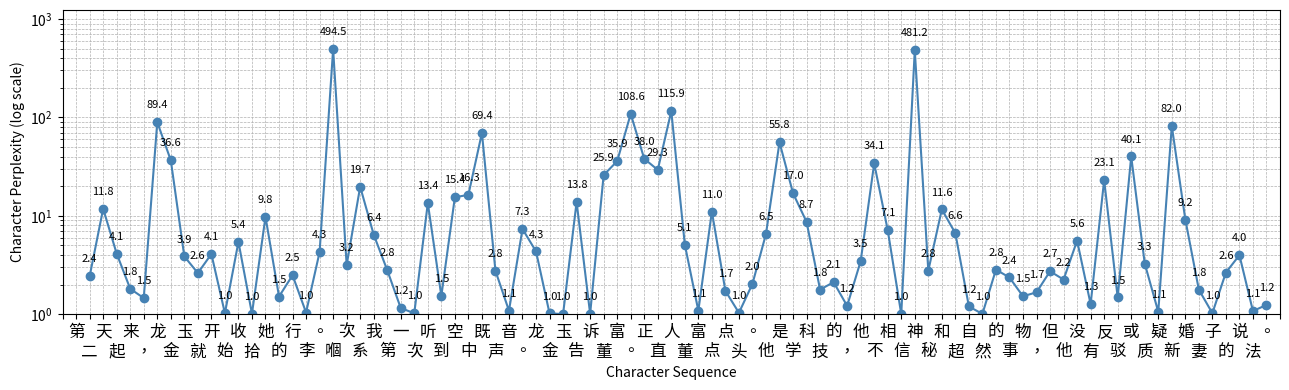

In [14]:
length = len(perplexities)
positions = np.arange(1, length + 1)
# Include padding in values array
values = np.full(length + 2, np.nan)
for i, (_, _, ppl) in enumerate(perplexities):
    if i == 0:
      ppl = np.nan
    values[i + 1] = ppl  # Shift values by 1 to account for left padding

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(positions, values[1:-1], marker='o', linestyle='-', color='steelblue')

for i, (_, _, ppl) in enumerate(perplexities):
    if not np.isnan(ppl):
        annotation_text = f"{round(ppl, 1)}"
        ax.annotate(annotation_text, (positions[i], values[i + 1]),
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

ax.set_xlabel('Character Sequence')
ax.set_ylabel('Character Perplexity (log scale)')
ax.set_xlim(0, length + 1)
ax.set_xticks(range(length + 2))
xticklabels = [''] + [char if i < len(perplexities) else '' for i, (char, _, _) in enumerate(perplexities)] + [''] * (length - len(perplexities) + 1)
xticklabels = ["\n" + label if i % 2 == 0 else label for i, label in enumerate(xticklabels)]
ax.set_xticklabels(xticklabels, fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_yscale('log')
ax.set_ylim(bottom=1, top=np.nanmax(values) * 2.5 if np.nanmax(values) > 0 else 10)
plt.tight_layout()
plt.savefig("perplexities.png", dpi=600, bbox_inches='tight')
plt.show()